**Day 1: Business Understanding**

This project aims to predict the **probability of financial inclusion** using the FinAccess Household Survey 2021 dataset. The unit of analysis is the **individual respondent**, where each row represents one surveyed person. The prediction task is framed as a **binary classification problem**.

A respondent will be classified as **financially included (`1`)** if they have at least one of the following: a **bank account**, a **mobile-money account**, or an **insurance product**. Otherwise, the respondent will be classified as **not financially included (`0`)**.

The initial predictor scope focuses on **demographics, location, income, education, trust, documentation barriers, and distance/access barriers**. For evaluation, the project will prioritize **Recall**, **F1-score**, and **ROC-AUC**.

**Day 2: Data Understanding**

The notebook below loads the FinAccess dataset, inspects the raw structure, and prepares the working dataset that matches the current project methodology.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Create the local destination first
!mkdir -p /content/project

# Copy from Drive to the local fast SSD
# Note: Folder names are case-sensitive! 
!cp -r "/content/drive/MyDrive/New project/"* /content/project/


In [3]:
import os
print(os.listdir("/content/drive/MyDrive/"))


['dat.ipynb', 'Sample - Superstore.csv', 'Copy of decision n random', 'MidMorning_Class_Project_Report (1).docx', 'WeekendAssignment_Students.pdf', 'archive (13).zip', 'Data science', 'Colab Notebooks', 'Updated Anonymized Weighted FinAccess 2021_clean.xlsx', 'New project']


In [4]:
# Create a folder in the cloud's local memory
!mkdir -p /content/project

# Copy files from your Google Drive folder to the cloud memory
!cp -r "/content/drive/MyDrive/New project/"* /content/project/

# Verify you can see your .csv and .pkl files
!ls /content/project/


 backups
 create_financial_inclusion_target.py
 CRISP_DM_7_DAY_ROADMAP.md
 fin_access_DESCRIPTION.md
 FINACCESS_DROP_COLUMNS.csv
 FINACCESS_FEATURE_GROUPS.md
 FINACCESS_KEEP_COLUMNS.csv
 FINACCESS_KEEP_DROP_LIST.csv
 FINACCESS_KEPT_COLUMNS_WITH_LABELS.csv
 FINACCESS_RENAME_TABLE.csv
 finaccess_select_and_rename.py
 METHODOLOGY_SECTION.md
 models_best.ipynb
'project frid.8.ipynb'
'project frid.ipynb'
 PROJECT_PROPOSAL.md
 REPORT_TEMPLATE_ROADMAP.md
 SECTION_3_3_PREPROCESSING_PARAGRAPH.md
'Updated Anonymized Weighted FinAccess 2021_clean.2.xlsx'
'Updated Anonymized Weighted FinAccess 2021_clean.xlsx'
 xlsx_probe
 zip_repair_output


In [5]:
from pathlib import Path
import pandas as pd

# Update this to the cloud path we created
BASE_DIR = Path("/content/project")

# These will now look in the cloud storage instead of your C: drive
DATA_FILE = BASE_DIR / "Updated Anonymized Weighted FinAccess 2021_clean.xlsx"
KEEP_FILE = BASE_DIR / "FINACCESS_KEEP_COLUMNS.csv"
RENAME_FILE = BASE_DIR / "FINACCESS_RENAME_TABLE.csv"

MISSING_CODE = -999999999

# Test if the data file is found
if DATA_FILE.exists():
    print("✅ Success: Data file found in Colab!")
else:
    print("❌ Error: Data file not found. Check if !cp command worked.")


✅ Success: Data file found in Colab!


In [6]:
!pip install -q openpyxl


In [7]:
df_raw = pd.read_excel(DATA_FILE, sheet_name="Dataset")

print("File successfully read as Excel.")
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

display(df_raw.head())

File successfully read as Excel.
Rows: 22024
Columns: 2332


,Serial Number,County,ClusterNo,HHNo,interview__key,interview__id,A9,A9i,A10i,A14v,...,allotherformal_banked2022,formal_banked2022,excluded_informal_banked2022,NHIF_health_insurance,NHIF_ONLY,Medical_Insurance_ONLY,BothNHIF_medical,Nomedical,NHIFMedical_Cat,adults
0,1,Trans Nzoia,10226038,1048,10-67-89-46,0003fc74b3fe418ea041bd6a9e7ff387,Rural,Access granted,Female,1,...,Yes,No,Other Formal,Yes,NaN,NaN,1.0,NaN,Users of NHIF + medical insurance (C1_42 and C...,1 adult Household
1,2,Busia,10240034,1080,39-64-68-81,0004890b17744272baf0a0c7b4c20771,Rural,Access granted,Female,4,...,No,Yes,Banked,Yes,1.0,NaN,NaN,NaN,"Users of NHIF only, with no medical insurance",>1 adult Household
2,3,Machakos,10216062,1013,92-34-74-01,00052153fe8c4abaa189caadcb87b2b4,Rural,Access granted,Male,1,...,No,No,Excluded,Yes,1.0,NaN,NaN,NaN,"Users of NHIF only, with no medical insurance",1 adult Household
3,4,Kisumu,10242078,1026,08-14-22-63,000d1f8747194b6a84862830dc5fe7ca,Rural,Access granted,Male,5,...,No,Yes,Banked,No,NaN,NaN,NaN,"Users of NHIF only, with no medical insurance",None users of any of NHIF and medical insurance,>1 adult Household
4,5,Nyeri,10219138,1019,99-12-05-84,000f5a5c0e3246ac9a62603ad936e3da,Urban,Access granted,Male,3,...,No,Yes,Banked,No,NaN,NaN,NaN,"Users of NHIF only, with no medical insurance",None users of any of NHIF and medical insurance,>1 adult Household


In [8]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22024 entries, 0 to 22023
Columns: 2332 entries, Serial Number to adults
dtypes: float64(206), int64(76), object(2050)
memory usage: 391.8+ MB


In [9]:
df_raw.describe(include="all").transpose().head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Serial Number,22024.0,NaN,NaN,NaN,11012.5,6357.9255,1.0,5506.75,11012.5,16518.25,22024.0
County,22024,47,Nakuru,805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClusterNo,22024.0,NaN,NaN,NaN,10199893.81611,45876.657928,10101017.0,10147167.0,10217170.0,10234034.0,10247290.0
HHNo,22024.0,NaN,NaN,NaN,1053.040501,37.992618,1001.0,1024.0,1048.0,1076.0,1557.0
interview__key,22024,22024,95-24-94-44,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
interview__id,22024,22024,fffc994169144ce2b6d112454cf59db2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A9,22024,2,Rural,14455,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A9i,22024,1,Access granted,22024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A10i,22024,2,Male,12998,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A14v,22024.0,NaN,NaN,NaN,2.328097,1.327928,1.0,1.0,2.0,3.0,13.0


- original_full_df: This is the DataFrame containing your raw, original data before any cleaning or filtering.
- .describe(include="all"): This method generates descriptive statistics of the DataFrame. By specifying include="all", it calculates statistics for both numerical and categorical columns. For numerical columns, it includes count, mean, standard deviation, min, max, and quartiles. For categorical columns, it includes count, unique values, top occurring value, and its frequency.
- .transpose(): By default, describe() outputs columns as rows and statistics as columns. Transposing (.transpose() or .T) swaps these, so column names become the index (rows) and the statistics become the columns. This often makes the output more readable when you have many columns.
- .head(20): This selects and displays only the first 20 rows of the resulting descriptive statistics table. This is useful for getting a quick overview without printing the statistics for all 2300+ columns.
 


## 3.3 Data Pre-Processing

### 3.3.1 Handling Missing Values

In [10]:
missing_data_raw = df_raw.isna().mean().mul(100).sort_values(ascending=False)

print("Columns with missing data in the raw dataset:")
display(missing_data_raw[missing_data_raw > 0].head(20))

columns_100_missing = missing_data_raw[missing_data_raw == 100].index.tolist()
print(f"Columns with 100% missing values in the raw dataset: {len(columns_100_missing)}")

Columns with missing data in the raw dataset:


,0
G1A68__17,100.0
G1A68__16,100.0
G1A68__15,100.0
G1B1a,100.0
U4i,100.0
G1A6a,100.0
P9i,100.0
G1B6a,100.0
L3i,100.0
M11Ai,100.0


Columns with 100% missing values in the raw dataset: 64


### 3.3.3 Feature Engineering and Encoding

In [11]:
columns_to_keep = pd.read_csv(KEEP_FILE, header=None)[0].tolist()
rename_df = pd.read_csv(RENAME_FILE)

coded_columns = [
    "ClusterNo", "A9", "A10i", "A19", "A21", "A21i", "A23", "B1H_I",
    "B3A__1", "B3A__2", "B3A__3", "B3A__4", "B3A__5", "B3A__6",
    "B3A__7", "B3A__8", "B3A__9", "B3I", "C4", "D1B__14", "D1C__14",
    "E3__9", "E3__17", "F2__12", "H1B__17", "J1__10", "K2__11",
    "N2__6", "T4", "T5", "T6", "T7", "T8", "T9"
]

rename_map = (
    rename_df[rename_df["original_name"].isin(coded_columns)]
    .set_index("original_name")["new_name"]
    .to_dict()
)

print(f"Columns to keep: {len(columns_to_keep)}")
print(f"Columns with rename mapping: {len(rename_map)}")
print("First 10 kept columns:")
print(columns_to_keep[:10])

Columns to keep: 47
Columns with rename mapping: 34
First 10 kept columns:
['County', 'ClusterNo', 'A9', 'A10i', 'A19', 'A21', 'A21i', 'A23', 'B1H_I', 'B3A__1']


columns outside the predefined keep list were excluded by subsetting the raw dataset to the selected working columns, thereby reducing the dataset from 2,332 columns to the final project-specific feature set.

 renaming only cryptic/original coded columns

In [12]:
df = df_raw.loc[:, columns_to_keep].copy()
# removes the columns and rows with 100% missing values and renames the columns with the new names provided in the rename map
df = df.rename(columns=rename_map)

print("Working dataset shape:", df.shape)
display(df.head())

Working dataset shape: (22024, 47)


,County,cluster_number,cluster_type,respondent_sex,respondent_age,education_completed_raw,education_completed_other,female_hh_highest_education,emergency_access_area_type,income_source_farming,...,education_anyHH,bank_usage,insurance_usage,mobile_bank_usage,mobile_money_usage,incomegp,mobile_money_access,mobile_money_active,incomegpnew,incomegp_new
0,Trans Nzoia,10226038,Rural,Female,59,Completed technical training after secondary s...,NaN,NaN,No,Yes,...,Tertiary,Currently have,Currently have,Never had,Currently have,KSh 7501-15000,Yes,Yes,"KSh 10,001-20,000",KSh 7501-15000
1,Busia,10240034,Rural,Female,43,Completed technical training after secondary s...,NaN,NaN,Yes,No,...,Tertiary,Used to have,Never had,Never had,Currently have,KSh 3001 - 7500,Yes,Yes,"KSh 5,001 - 10,000",KSh 3001 - 7500
2,Machakos,10216062,Rural,Male,72,"""Some primary """,NaN,No female household head/spouse,No,Yes,...,Primary,Never had,Never had,Never had,Never had,KSh 101 - 1500,No,No,"KSh 1 - 1,000",< KSh 3000
3,Kisumu,10242078,Rural,Male,22,"""Primary completed""",NaN,Some primary,No,No,...,Primary,Never had,Never had,Never had,Currently have,KSh 1501 - 3000,Yes,Yes,"KSh 1,001 - 3,000",< KSh 3000
4,Nyeri,10219138,Urban,Male,36,"""Primary completed""",NaN,NaN,No,No,...,Primary,Never had,Never had,Never had,Currently have,Don't Know,Yes,Yes,Don't Know,Others


In [13]:
df = df.replace(MISSING_CODE, pd.NA)

missing_data_working = df.isna().mean().mul(100).sort_values(ascending=False)
print("Missing data in the working dataset after recoding -999999999:")
display(missing_data_working[missing_data_working > 0])

Missing data in the working dataset after recoding -999999999:


,0
education_completed_other,99.909190
loan_barrier_inadequate_documentation,99.877406
insurance_doc_barrier_no_insurance,99.854704
insurance_doc_barrier_not_in_own_name,99.273520
cost_to_nearest_mobile_money_agent,97.493643
walk_time_to_nearest_mobile_money_agent,97.493643
loan_barrier_low_income_to_repay,89.779332
mobile_money_barrier_untrustworthy_agents,78.918453
savings_barrier_distrust_institutions,73.270069
female_hh_highest_education,47.634399


In [14]:
original_columns = df_raw.columns.tolist()
dropped_columns = [col for col in original_columns if col not in columns_to_keep]

print(f"Original columns: {len(original_columns)}")
print(f"Kept columns: {len(columns_to_keep)}")
print(f"Dropped columns: {len(dropped_columns)}")

print("First 20 dropped columns:")
print(dropped_columns[:20])

Original columns: 2332
Kept columns: 47
Dropped columns: 2285
First 20 dropped columns:
['Serial Number', 'HHNo', 'interview__key', 'interview__id', 'A9i', 'A14v', 'A14vi', 'A15', 'A15i', 'A17', 'A18', 'A20', 'A22', 'A24', 'A25', 'A26__1', 'A26__2', 'A26__3', 'A26__4', 'A26__5']


Columns outside the selected project scope were dropped to reduce dimensionality and keep the dataset focused on the prediction objective. Since this study aims to predict financial inclusion using demographics, location, income, education, trust, documentation barriers, and distance/access variables, only columns directly relevant to these themes were retained.

In [15]:
def create_financial_inclusion_target(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a binary financial inclusion target from:
    - bank_usage
    - mobile_money_usage
    - insurance_usage

    A respondent is financially included (1) if they currently have
    at least one of the three financial products.
    """
    target_columns = [
        "bank_usage",
        "mobile_money_usage",
        "insurance_usage",
    ]

    out = df.copy()

    # Standardize missing values
    out[target_columns] = out[target_columns].fillna("Never had")

    # Create binary target from text labels
    out["financially_included"] = (
        (out["bank_usage"] == "Currently have")
        | (out["mobile_money_usage"] == "Currently have")
        | (out["insurance_usage"] == "Currently have")
    ).astype(int)

    return out


creation of my target variable


In [16]:
df = create_financial_inclusion_target(df)

display(
    df[
        [
            "bank_usage",
            "mobile_money_usage",
            "insurance_usage",
            "financially_included",
        ]
    ].head()
)

print(df["financially_included"].value_counts(dropna=False))
print("Proportion financially included:", df["financially_included"].mean())

,bank_usage,mobile_money_usage,insurance_usage,financially_included
0,Currently have,Currently have,Currently have,1
1,Used to have,Currently have,Never had,1
2,Never had,Never had,Never had,0
3,Never had,Currently have,Never had,1
4,Never had,Currently have,Never had,1


financially_included
1    17399
0     4625
Name: count, dtype: int64
Proportion financially included: 0.7900018162005086


The engineered target variable showed that 17,399 respondents, representing 79.0% of the sample, were classified as financially included, while 4,625 respondents, representing 21.0%, were classified as not financially included. This indicates a moderate class imbalance, which was taken into account during model evaluation by emphasizing metrics beyond overall accuracy.

In [17]:
print(df["financially_included"].value_counts(dropna=False))


financially_included
1    17399
0     4625
Name: count, dtype: int64


## At this stage, the dataset has been filtered, renamed, and used to create the binary target variable, but categorical predictors have not yet been encoded for modeling.

In [18]:
categorical_cols = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumeric columns:")
print(numeric_cols)


Categorical columns:
['County', 'cluster_type', 'respondent_sex', 'education_completed_raw', 'education_completed_other', 'female_hh_highest_education', 'emergency_access_area_type', 'income_source_farming', 'income_source_employment', 'income_source_casual_work', 'income_source_self_employment', 'income_source_social_transfer', 'income_source_rental_income', 'income_source_investments', 'income_source_pension_annuity', 'income_source_family_support', 'monthly_income_ksh', 'trusted_financial_provider', 'insurance_doc_barrier_no_insurance', 'insurance_doc_barrier_not_in_own_name', 'loan_barrier_low_income_to_repay', 'loan_barrier_inadequate_documentation', 'savings_barrier_distrust_institutions', 'bank_barrier_distrust_banks', 'sacco_barrier_lack_of_trust', 'mobile_money_barrier_untrustworthy_agents', 'formal_account_barrier_distrust', 'cost_to_nearest_bank', 'walk_time_to_nearest_bank', 'cost_to_nearest_mobile_money_agent', 'walk_time_to_nearest_mobile_money_agent', 'cost_to_nearest_ba

In [19]:
exclude_from_predictors = [
    "bank_usage",
    "mobile_money_usage",
    "insurance_usage",
    "financially_included",
    "Serial Number",
    "interview__key",
    "interview__id",
    "ClusterNo",
    "HHNo"
]

categorical_predictors = [col for col in categorical_cols if col not in exclude_from_predictors]
numeric_predictors = [col for col in numeric_cols if col not in exclude_from_predictors]

print("Categorical predictor columns:")
print(categorical_predictors)

print("\nNumeric predictor columns:")
print(numeric_predictors)


Categorical predictor columns:
['County', 'cluster_type', 'respondent_sex', 'education_completed_raw', 'education_completed_other', 'female_hh_highest_education', 'emergency_access_area_type', 'income_source_farming', 'income_source_employment', 'income_source_casual_work', 'income_source_self_employment', 'income_source_social_transfer', 'income_source_rental_income', 'income_source_investments', 'income_source_pension_annuity', 'income_source_family_support', 'monthly_income_ksh', 'trusted_financial_provider', 'insurance_doc_barrier_no_insurance', 'insurance_doc_barrier_not_in_own_name', 'loan_barrier_low_income_to_repay', 'loan_barrier_inadequate_documentation', 'savings_barrier_distrust_institutions', 'bank_barrier_distrust_banks', 'sacco_barrier_lack_of_trust', 'mobile_money_barrier_untrustworthy_agents', 'formal_account_barrier_distrust', 'cost_to_nearest_bank', 'walk_time_to_nearest_bank', 'cost_to_nearest_mobile_money_agent', 'walk_time_to_nearest_mobile_money_agent', 'cost_to_

above I have excluded the target creator columns to prevent data leakage as well as the final target itself

In [20]:
# Numerical and categorical columns
#separate the numerical and categorical columns for later use in preprocessing
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

In [21]:
#Numerical columns → Median imputation (robust to outliers)
#Categorical columns → Mode imputation (most frequent value)

imputation_report = {}

# Numerical columns → Median
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        imputation_report[col] = f"Median ({median_value})"

# Categorical columns → Mode
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        imputation_report[col] = f"Mode ({mode_value})"

/tmp/ipykernel_4666/411620782.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)


In [22]:
#Show what was applied
print("\nImputation methods used:")
for col, method in imputation_report.items():
    print(f"{col}: {method}")


Imputation methods used:
education_completed_other: Mode (Masters)
female_hh_highest_education: Mode ("None")
trusted_financial_provider: Mode (A bank)
insurance_doc_barrier_no_insurance: Mode (Yes)
insurance_doc_barrier_not_in_own_name: Mode (Yes)
loan_barrier_low_income_to_repay: Mode (No)
loan_barrier_inadequate_documentation: Mode (Yes)
savings_barrier_distrust_institutions: Mode (No)
bank_barrier_distrust_banks: Mode (No)
sacco_barrier_lack_of_trust: Mode (No)
mobile_money_barrier_untrustworthy_agents: Mode (No)
formal_account_barrier_distrust: Mode (No)
cost_to_nearest_bank: Mode (Between KSh 51- 100)
walk_time_to_nearest_bank: Mode (More than 3 hours)
cost_to_nearest_mobile_money_agent: Mode (Close enough to walk  No need to spend)
walk_time_to_nearest_mobile_money_agent: Mode ("Don't know(DO NOT READ OUT)")
cost_to_nearest_bank_agent: Mode (Close enough to walk to and fro -  No need to spend)
walk_time_to_nearest_bank_agent: Mode (About 10 to 30 minutes)
education: Mode (Prima

In [23]:
#Final check for any remaining missing values
print("\nRemaining missing values:\n", df.isnull().sum().sum())



Remaining missing values:
 0


# below

In [24]:
target_columns = [
    "bank_usage",
    "mobile_money_usage",
    "insurance_usage",
]

df[target_columns] = df[target_columns].fillna("Never had")
df["financially_included"] = (
    (df["bank_usage"] == "Currently have")
    | (df["mobile_money_usage"] == "Currently have")
    | (df["insurance_usage"] == "Currently have")
).astype(int)


In [25]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import pandas as pd

# Define target
target_col = "financially_included"

# Columns to exclude (leakage prevention)
exclude_from_predictors = [
    "bank_usage",
    "mobile_money_usage",
    "insurance_usage",
    "financially_included",
    "Serial Number",
    "interview__key",
    "interview__id",
    "ClusterNo",
    "HHNo"
]

# Detect column types
categorical_cols = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

# Build predictor lists
categorical_predictors = [col for col in categorical_cols if col not in exclude_from_predictors]
numeric_predictors = [col for col in numeric_cols if col not in exclude_from_predictors]

# Clean column names
df.columns = df.columns.str.strip()

# Drop safely
X = df.drop(columns=exclude_from_predictors, errors='ignore')
y = df[target_col]

# Fix categorical types
for col in categorical_predictors:
    X[col] = X[col].astype(str)

# Fix numeric types
for col in numeric_predictors:
    X[col] = pd.to_numeric(X[col], errors='coerce')



# Define transformers
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# Combine transformers into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_predictors),
        ('cat', categorical_transformer, categorical_predictors)
    ]
)
# Fit and transform the data
X_processed = preprocessor.fit_transform(X)

# EDA ONLY

feature_names = preprocessor.get_feature_names_out()

X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

X_processed_df["financially_included"] = y.values

print(X_processed_df.shape)
X_processed_df.head()

(22024, 474)


,num__cluster_number,num__respondent_age,cat__County_Baringo,cat__County_Bomet,cat__County_Bungoma,cat__County_Busia,cat__County_Elgeyo-Marakwet,cat__County_Embu,cat__County_Garissa,cat__County_Homabay,...,"cat__incomegpnew_KSh 50,001 - 100,000",cat__incomegpnew_Refused to Answer,cat__incomegp_new_< KSh 3000,cat__incomegp_new_> KSh 70000,cat__incomegp_new_KSh 15001 - 30000,cat__incomegp_new_KSh 30001 - 70000,cat__incomegp_new_KSh 3001 - 7500,cat__incomegp_new_KSh 7501-15000,cat__incomegp_new_Others,financially_included
0,0.569893,1.168038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
1,0.874979,0.238409,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
2,0.352435,1.923362,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.919534,-0.981729,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.419486,-0.168304,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1


Categorical predictors were encoded using one-hot encoding, while numeric predictors were standardized using z-score scaling. Target-source variables used to construct the binary target were excluded from the predictor matrix to avoid target leakage.

**Z‑score scaling** (also called **standardization** or **z‑score normalization**) is a feature‑scaling technique that transforms each numeric feature so that it has:

- a **mean of 0**, and  
- a **standard deviation of 1**.  


### Why it matters in data science

- It puts all numeric features on a **common scale**, so algorithms that care about distance or magnitude (e.g., SVM, k‑NN, logistic regression, and many deep‑learning models) are not dominated by features with large raw units (like “income in KSh” vs “age in years”).  
- It helps **gradient‑based optimizers** (like in neural networks) converge faster and more stably.  
- It is widely used in preprocessing pipelines (e.g., `StandardScaler` in scikit‑learn).

In short: **z‑score scaling standardizes your data into a “number of standard deviations from the mean” scale**, which is usually more suitable for many machine‑learning models than raw, unscaled values.

What this does:

- identifies categorical columns
- identifies numeric columns
- removes leakage columns from predictors
- defines X and y
- prepares the encoding/scaling pipeline for modeling

** Important note **

This encoding pipeline is best for:

Logistic Regression
Decision Tree
Random Forest
XGBoost
LightGBM
shallow DNN
TabM - if you use a preprocessing-based tabular setup

For CatBoost, you may want a separate workflow because CatBoost can often handle categorical variables directly.

The dataset initially contained 47 features, which expanded to 496 features after one-hot encoding of categorical variables. This transformation increased dimensionality, making correlation analysis less interpretable. Therefore, feature importance methods were used to better understand key predictors.

Encoding

Categorical variables with multiple categories were transformed using one-hot encoding, where each category was represented as a separate binary feature. This allowed the model to process categorical information effectively.

# outlier detection and handling

In [26]:
# Detect outliers using IQR
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary[col] = len(outliers)

print("Outliers per column:\n", outlier_summary)

Outliers per column:
 {'cluster_number': 0, 'respondent_age': 293, 'financially_included': 4625}


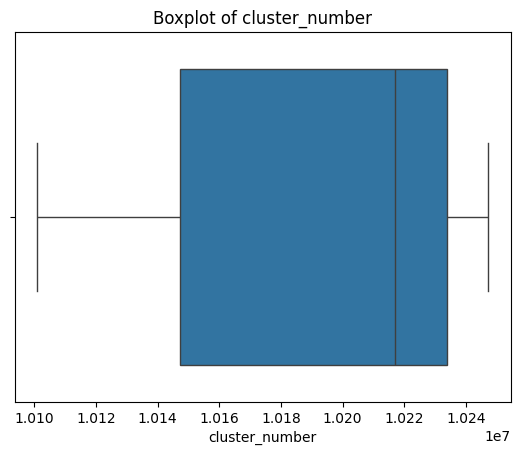

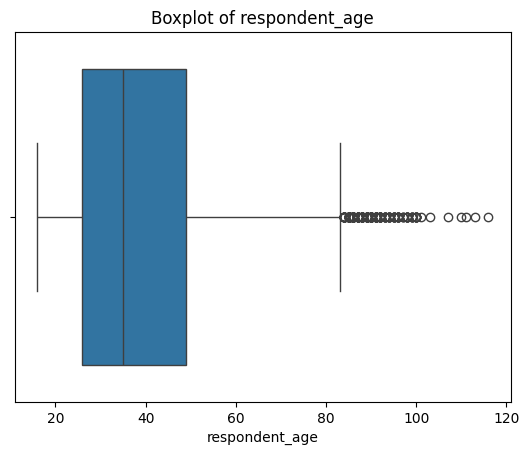

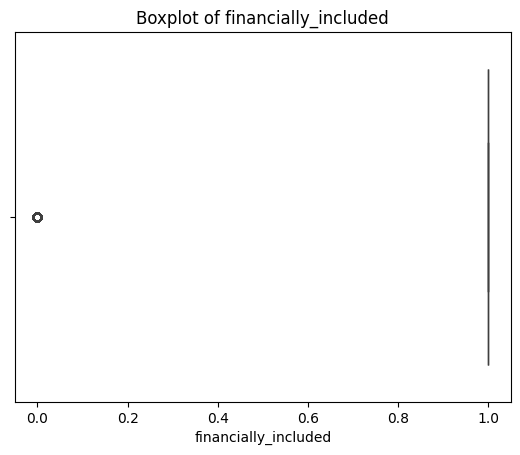

In [27]:
# Visualize outliers with boxplots
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

A boxplot was not appropriate for the binary target variable, as it led to misleading interpretation. Instead, class distribution was analyzed using count plots, which showed that approximately 79% of individuals were financially included, indicating moderate class imbalance.

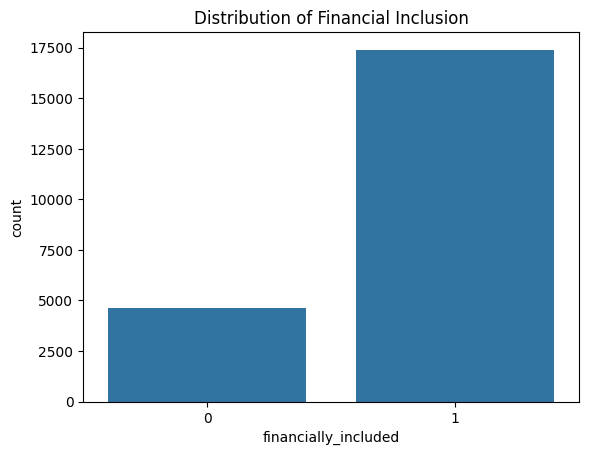

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["financially_included"])
plt.title("Distribution of Financial Inclusion")
plt.show()

## Treat Outliers

In [29]:
# Cap outliers using IQR method
import numpy as np
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

The notebook is now set up to run cleanly from top to bottom for the current project scope. The next logical sections are:

- **3.4 Exploratory Data Analysis (EDA)**
- **3.5 Analytical / Modelling Approach**
- **3.6 Evaluation Metrics**

In [30]:
y = X_processed_df['financially_included']

# Counts
print(y.value_counts())

# Percentages
print("\nPercentage distribution:")
print(y.value_counts(normalize=True) * 100)

financially_included
1    17399
0     4625
Name: count, dtype: int64

Percentage distribution:
financially_included
1    79.000182
0    20.999818
Name: proportion, dtype: float64


## 3.4 Exploratory Data Analysis

## Univariate analysis##

In [31]:
import os

os.environ["MPLCONFIGDIR"] = str(BASE_DIR / ".matplotlib")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


This plot shows the class distribution of the target variable `financially_included` to check whether the dataset is balanced before modeling.

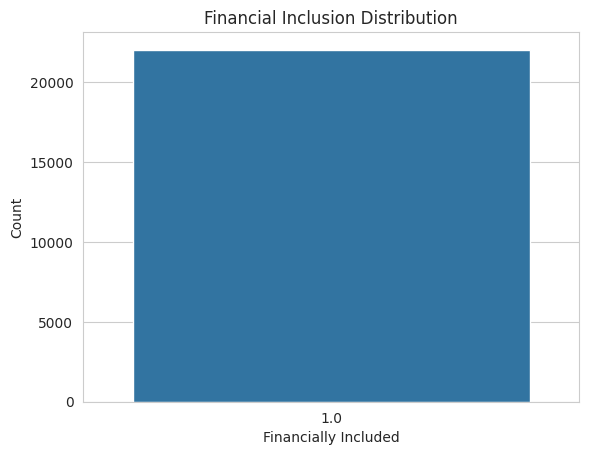

In [32]:
sns.countplot(x="financially_included", data=df)
plt.title("Financial Inclusion Distribution")
plt.xlabel("Financially Included")
plt.ylabel("Count")
plt.show()


This plot shows the distribution of respondents by sex in order to understand the composition of the sample.

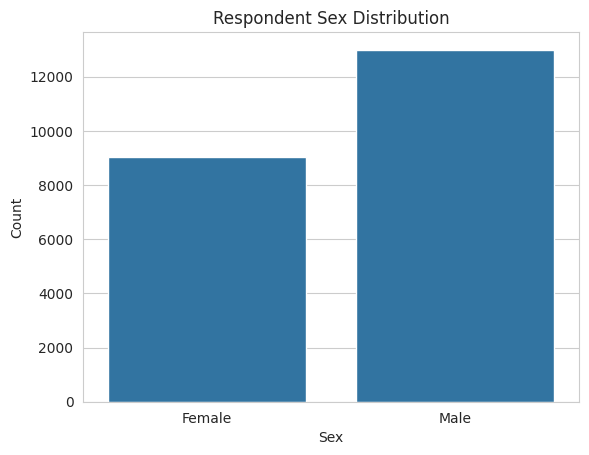

In [33]:
sns.countplot(x="respondent_sex", data=df)
plt.title("Respondent Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()


This plot shows the distribution of education levels among respondents, which helps assess whether educational attainment may be an important predictor of financial inclusion.

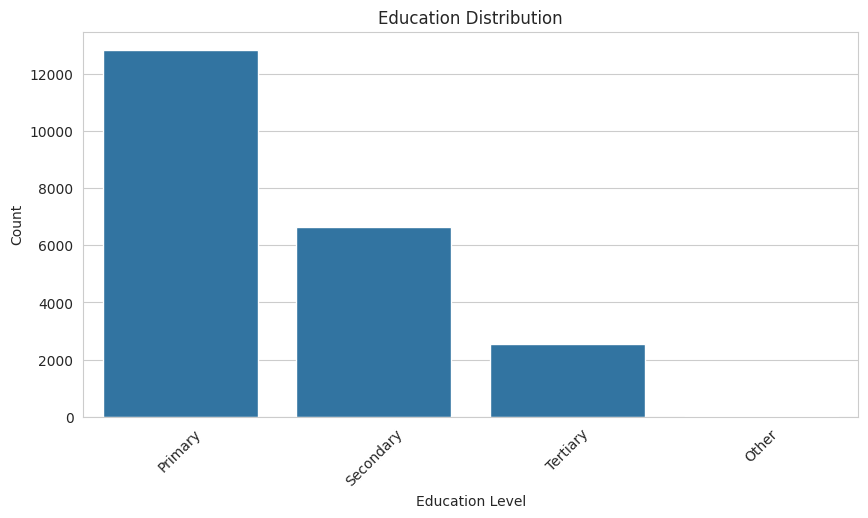

In [34]:
plt.figure(figsize=(10, 5))
sns.countplot(x="education", data=df, order=df["education"].value_counts().index)
plt.title("Education Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


This plot shows the distribution of monthly income categories in the dataset to highlight the income profile of the respondents.

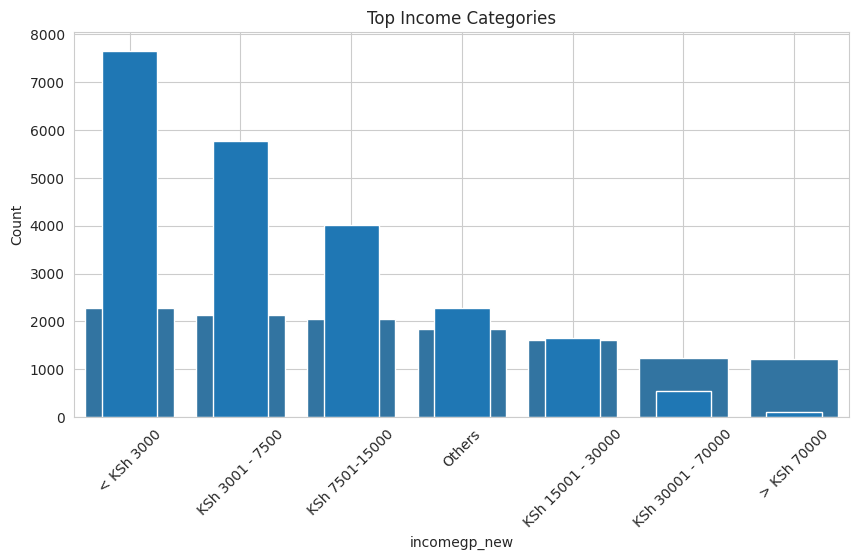

In [35]:
plt.figure(figsize=(10, 5))
sns.countplot(x="monthly_income_ksh", data=df, order=df["monthly_income_ksh"].value_counts().index)
income_col = "incomegp_new"

df[income_col] = df[income_col].replace([
    "Don't know/DO NOT READ",
    "Refused to Answer"
], "Unknown")

top_income = df[income_col].value_counts().head(10)

top_income.plot(kind="bar")
plt.title("Top Income Categories")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()



This plot shows how respondents are distributed across trust-related categories, which is useful because trust is one of the barriers considered in the study.

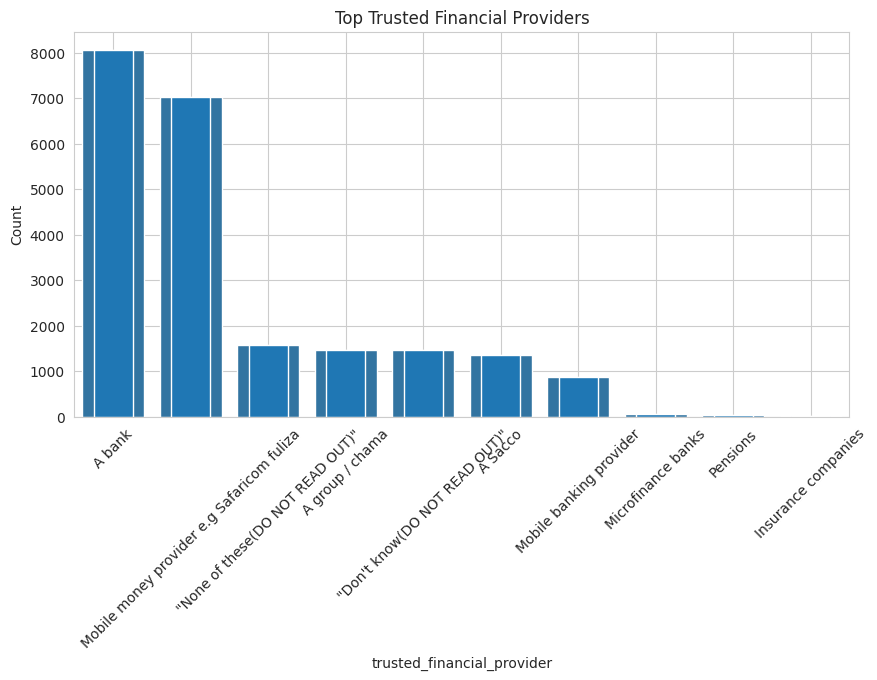

In [36]:
plt.figure(figsize=(10, 5))
sns.countplot(
    x="trusted_financial_provider",
    data=df,
    order=df["trusted_financial_provider"].value_counts().index,
)
provider_col = "trusted_financial_provider"

df[provider_col] = df[provider_col].replace([
    "Don't know/DO NOT READ",
    "Refused to Answer"
], "Unknown")
top_providers = df[provider_col].value_counts().head(10)

top_providers.plot(kind="bar")
plt.title("Top Trusted Financial Providers")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

This histogram shows the age distribution of respondents and helps identify the general age profile represented in the dataset.

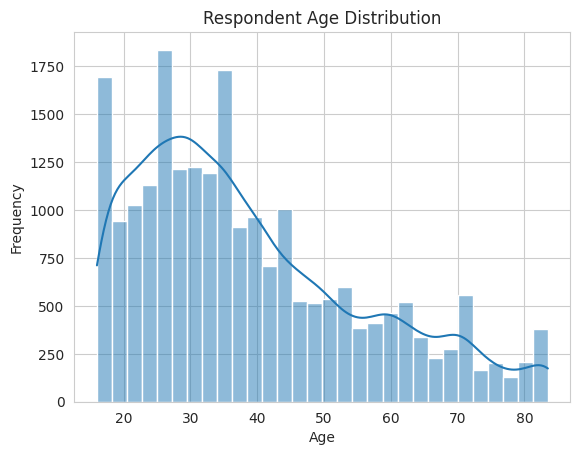

In [37]:
sns.histplot(df["respondent_age"].dropna(), bins=30, kde=True)
plt.title("Respondent Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


## Bivariate analysis##

This plot compares respondent sex with `financially_included` in order to show whether financial inclusion differs across sex categories.

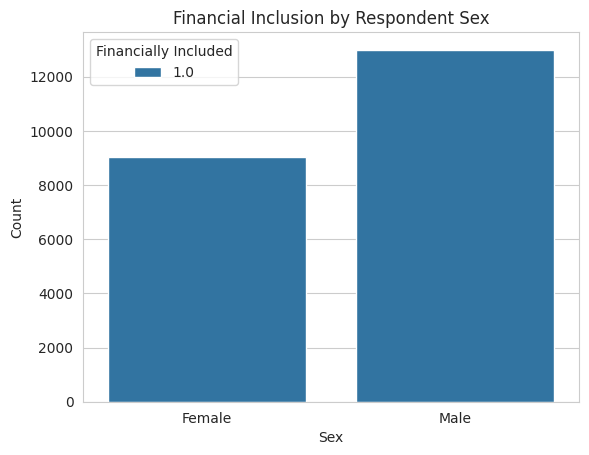

In [38]:
sns.countplot(x="respondent_sex", hue="financially_included", data=df)
plt.title("Financial Inclusion by Respondent Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Financially Included")
plt.show()


This plot compares education levels with `financially_included` to assess whether respondents with different education levels show different inclusion patterns.

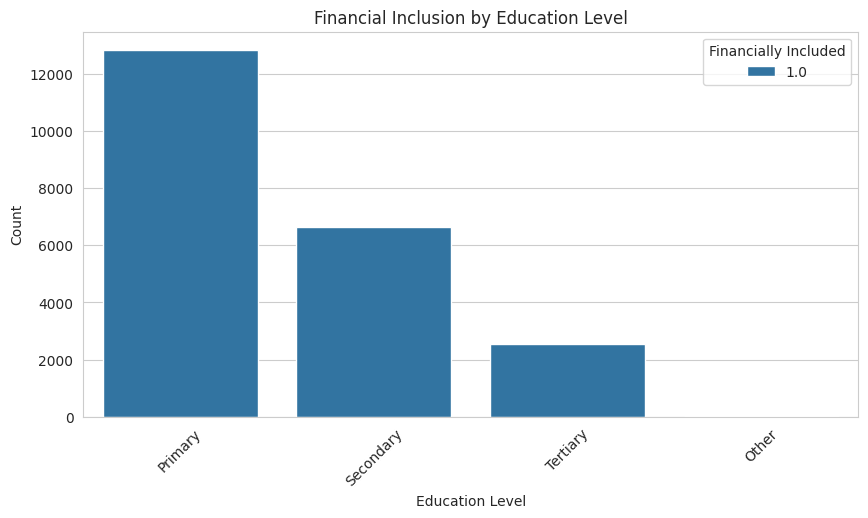

In [39]:
plt.figure(figsize=(10, 5))
sns.countplot(x="education", hue="financially_included", data=df, order=df["education"].value_counts().index)
plt.title("Financial Inclusion by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Financially Included")
plt.show()


This plot compares monthly income categories with `financially_included` to show whether inclusion appears to vary across income groups.

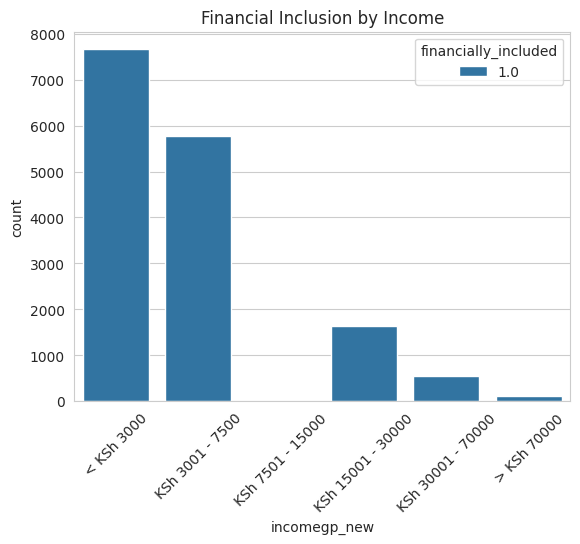

In [40]:
order = [
    "< KSh 3000",
    "KSh 3001 - 7500",
    "KSh 7501 - 15000",
    "KSh 15001 - 30000",
    "KSh 30001 - 70000",
    "> KSh 70000"
]

sns.countplot(
    data=df,
    x="incomegp_new",
    hue="financially_included",
    order=order
)

plt.xticks(rotation=45)
plt.title("Financial Inclusion by Income")
plt.show()

This plot compares trust-related categories with `financially_included` to explore whether trust in financial providers is associated with inclusion status.

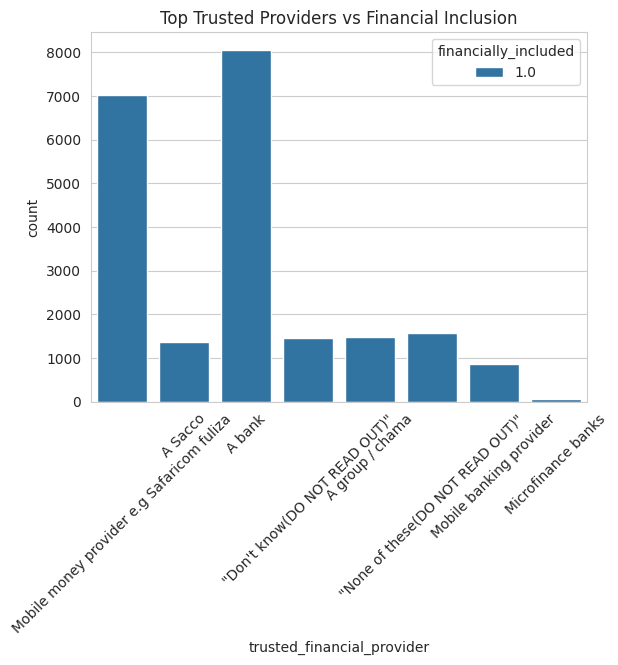

In [41]:
top_providers = df["trusted_financial_provider"].value_counts().head(8).index

filtered_df = df[df["trusted_financial_provider"].isin(top_providers)]

sns.countplot(
    data=filtered_df,
    x="trusted_financial_provider",
    hue="financially_included"
)

plt.xticks(rotation=45)
plt.title("Top Trusted Providers vs Financial Inclusion")
plt.show()

This box plot compares the age distribution across the two target classes in order to see whether financially included and excluded respondents differ in age.

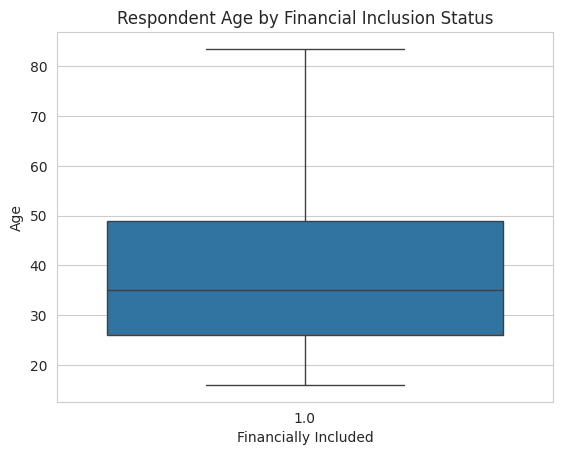

In [42]:
sns.boxplot(x="financially_included", y="respondent_age", data=df)
plt.title("Respondent Age by Financial Inclusion Status")
plt.xlabel("Financially Included")
plt.ylabel("Age")
plt.show()


## Multivariate analysis

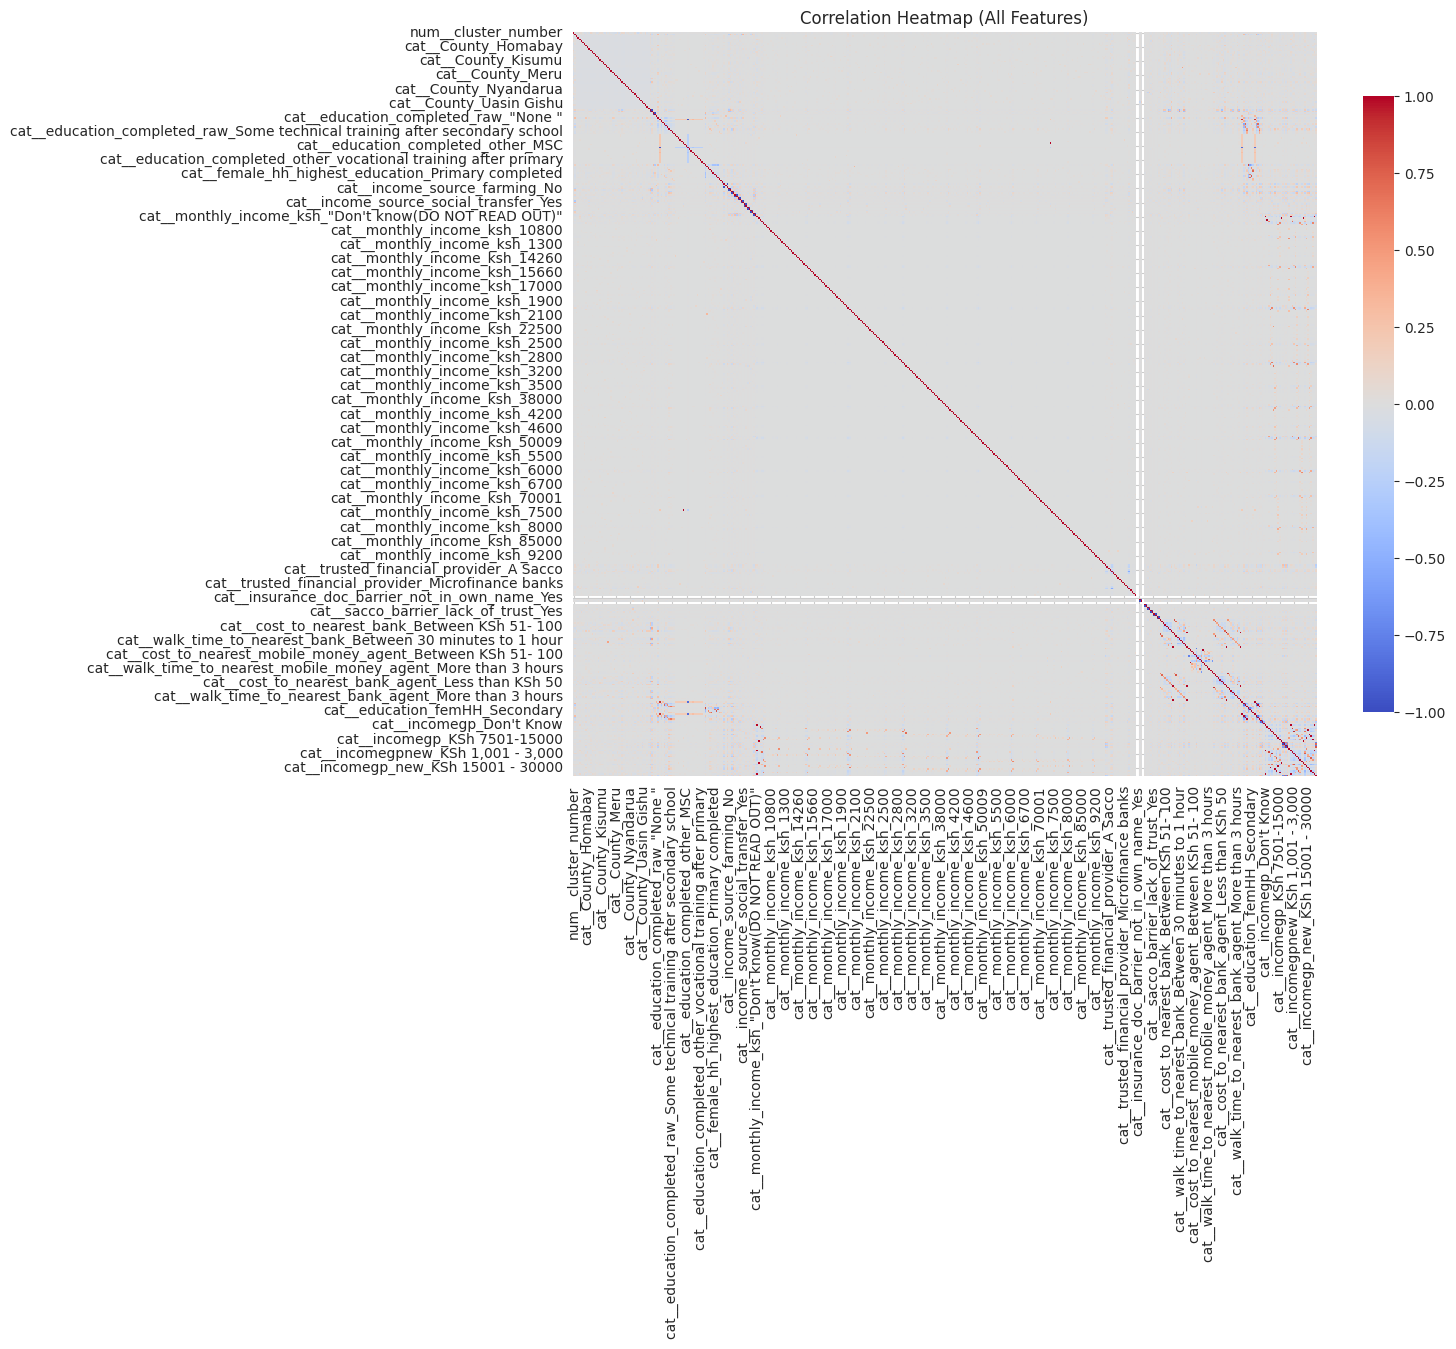

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
## Correlation Heatmap (ALL features + target)
# Compute correlation matrix
corr_matrix = X_processed_df.corr()

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Heatmap (All Features)")
plt.show()

Correlation interpretation

The correlation heatmap showed generally low correlations between features, indicating minimal multicollinearity. This suggests that the high model performance is not due to redundancy among features but rather strong relationships between individual features and the target variable.

In [44]:
# Correlation with target
target_corr = X_processed_df.corr()["financially_included"].drop("financially_included")

# Sort values
target_corr = target_corr.sort_values(ascending=False)

print(target_corr.head(10))   # top positive
print(target_corr.tail(10))   # top negative

cat__mobile_money_active_Yes             0.774790
cat__mobile_money_access_Yes             0.714262
cat__mobile_bank_usage_Currently have    0.261813
cat__income_source_family_support_No     0.228932
cat__education_anyHH_Tertiary            0.170228
cat__education_Tertiary                  0.170228
cat__cluster_type_Urban                  0.144934
cat__income_source_employment_Yes        0.139803
cat__incomegp_KSh 7501-15000             0.138920
cat__incomegp_new_KSh 7501-15000         0.138920
Name: financially_included, dtype: float64
cat__incomegp_KSh 101 - 1500                                    -0.212878
cat__incomegpnew_KSh 1 - 1,000                                  -0.225901
cat__income_source_family_support_Yes                           -0.228932
cat__trusted_financial_provider_"Don't know(DO NOT READ OUT)"   -0.253190
cat__mobile_bank_usage_Never had                                -0.291736
cat__mobile_money_access_No                                     -0.714262
cat__mobile_m

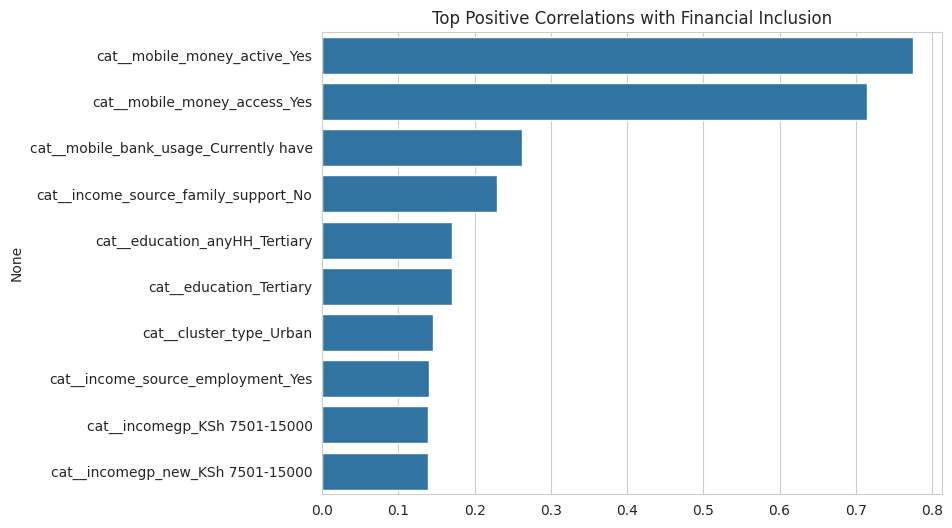

In [46]:
## Visualize TOP correlations
top_features = target_corr.head(10)
bottom_features = target_corr.tail(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top Positive Correlations with Financial Inclusion")
plt.show()


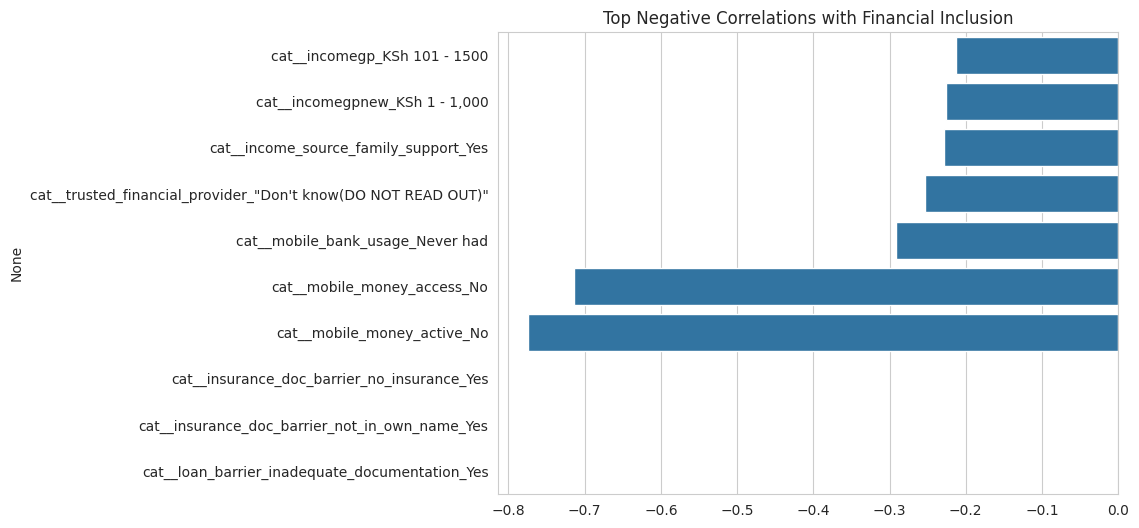

In [47]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=bottom_features.values,
    y=bottom_features.index
)

plt.title("Top Negative Correlations with Financial Inclusion")
plt.show()

### 3.5 Analytical / Modelling Approach

#### 3.5.1 Model Selection and Justification

## Logistic Regression Model(Baseline Model)

1. Build the pipeline

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression

log_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", VarianceThreshold(0.01)),
    ("model", LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

2. Train the model

In [49]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

3. Predictions

In [50]:
log_pipeline.fit(X_train, y_train)
y_pred = log_pipeline.predict(X_test)
y_prob = log_pipeline.predict_proba(X_test)[:, 1]

In [51]:
preprocessor_fitted = log_pipeline.named_steps["preprocessing"]
selector = log_pipeline.named_steps["feature_selection"]

all_feature_names = preprocessor_fitted.get_feature_names_out()
selected_features = all_feature_names[selector.get_support()]

coeffs = log_pipeline.named_steps["model"].coef_[0]

importance = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": coeffs
}).sort_values(by="Coefficient", ascending=False)

print(importance.head(15))

                                               Feature  Coefficient
154              cat__mobile_bank_usage_Currently have     3.592737
167                       cat__mobile_money_active_Yes     2.652539
165                       cat__mobile_money_access_Yes     1.585275
41                              cat__County_Tana River     1.180273
20                                   cat__County_Kwale     1.086730
58   cat__education_completed_raw_"University compl...     1.015091
95                        cat__monthly_income_ksh_3500     0.830601
47                                   cat__County_Wajir     0.654295
21                                cat__County_Laikipia     0.650920
25                                 cat__County_Mandera     0.634546
61        cat__education_completed_raw_Some university     0.619818
129  cat__cost_to_nearest_mobile_money_agent_Close ...     0.603100
105            cat__trusted_financial_provider_A Sacco     0.598854
10                                  cat__County_

4. Evaluation (VERY IMPORTANT)

In [52]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9212258796821794
Precision: 0.9918367346938776
Recall: 0.9077586206896552
F1 Score: 0.9479369842460615
ROC-AUC: 0.980129853991923

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.97      0.84       925
           1       0.99      0.91      0.95      3480

    accuracy                           0.92      4405
   macro avg       0.86      0.94      0.89      4405
weighted avg       0.94      0.92      0.92      4405



5. Confusion Matrix

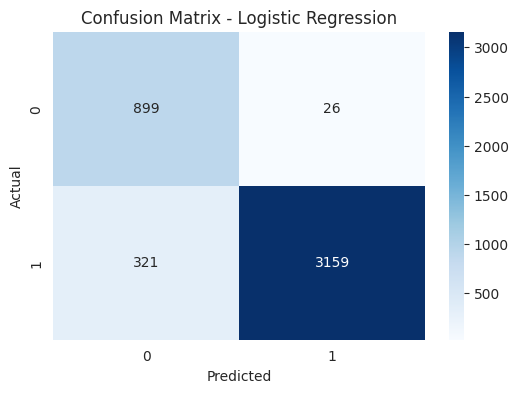

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Random forest model

In [54]:
# 1. Build the pipeline (same structure)

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", VarianceThreshold(0.01)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

In [55]:
## 2. Train the model
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['cluster_number',
                                                   'respondent_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['County', 'cluster_type',
                                                   'respondent_sex',
                                                   'education_completed_raw',
                                                   'education_completed_other',
                                                   'female_hh_highest_education',
                                                   'emergency_access_area_type',
                                                   'in...
                                                   'sacco_barrier_lack_of_trust',
                                                   'mobile_money_barrier_untrustworthy_agents',
                                                   'formal_account_barrier_distrust',
                                                   'cost_to_nearest_bank',
                                                   'walk_time_to_nearest_bank',
                                                   'cost_to_nearest_mobile_money_agent', ...])])),
                ('feature_selection', VarianceThreshold(threshold=0.01)),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [56]:
# 3. Predictions
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

### 4. Evaluate (same metrics for fair comparison)

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 3. Predictions
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Precision: 0.9529611788041938
Recall: 0.9663793103448276
F1 Score: 0.9596233414181766
ROC-AUC: 0.9823979496738118

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.82      0.84       925
           1       0.95      0.97      0.96      3480

    accuracy                           0.94      4405
   macro avg       0.91      0.89      0.90      4405
weighted avg       0.93      0.94      0.94      4405



### Feature Importance

In [58]:
# Get components
preprocessor_fitted = rf_pipeline.named_steps["preprocessing"]
selector = rf_pipeline.named_steps["feature_selection"]
model = rf_pipeline.named_steps["model"]

# Get feature names
all_features = preprocessor_fitted.get_feature_names_out()
selected_features = all_features[selector.get_support()]

# Get importances
importances = model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(15))

                                               Feature  Importance
167                       cat__mobile_money_active_Yes    0.227410
166                        cat__mobile_money_active_No    0.219852
164                        cat__mobile_money_access_No    0.087206
165                       cat__mobile_money_access_Yes    0.072509
1                                  num__respondent_age    0.040879
155                   cat__mobile_bank_usage_Never had    0.025054
154              cat__mobile_bank_usage_Currently have    0.020697
0                                  num__cluster_number    0.017693
83               cat__income_source_family_support_Yes    0.010264
103  cat__trusted_financial_provider_"Don't know(DO...    0.007777
82                cat__income_source_family_support_No    0.007621
175                       cat__incomegp_new_< KSh 3000    0.007416
158                       cat__incomegp_KSh 101 - 1500    0.007082
146                            cat__education_Tertiary    0.00

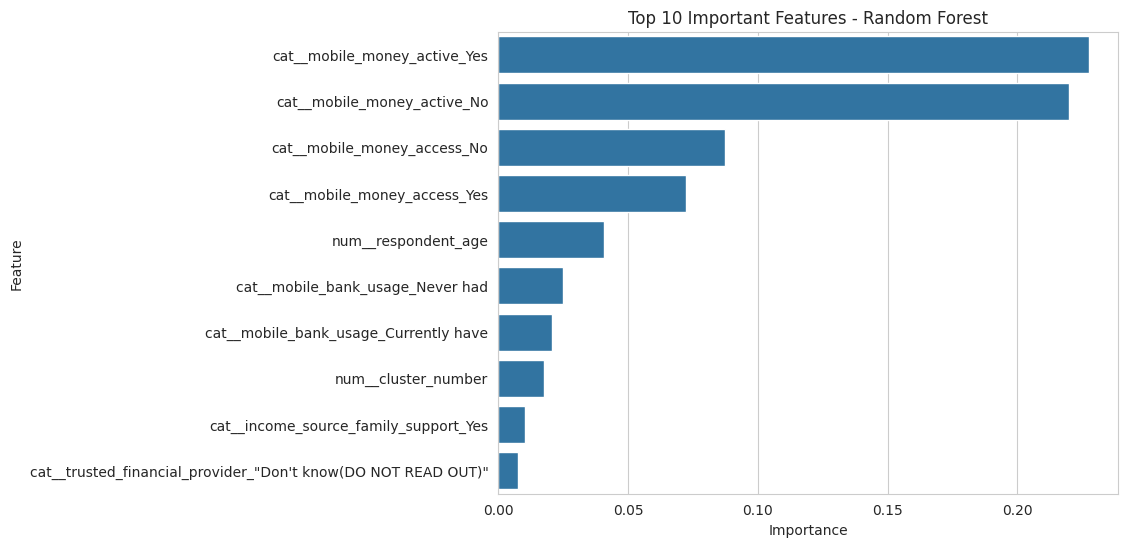

In [59]:
# Plot top features
import seaborn as sns
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 10 Important Features - Random Forest")
plt.show()

## Decision Tree (simple baseline)

In [60]:
from sklearn.tree import DecisionTreeClassifier
#pipeline for Decision Tree with similar structure to previous models, but with specific hyperparameters to prevent overfitting and handle class imbalance
dt_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", VarianceThreshold(0.01)),
    ("model", DecisionTreeClassifier(
        max_depth=10,           # prevents overfitting
        min_samples_split=10,
        random_state=42,
        class_weight='balanced'
    ))
])

In [61]:
# Train + Evaluate
dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)
y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

              precision    recall  f1-score   support

           0       0.74      0.96      0.84       925
           1       0.99      0.91      0.95      3480

    accuracy                           0.92      4405
   macro avg       0.86      0.94      0.89      4405
weighted avg       0.94      0.92      0.92      4405

ROC-AUC: 0.9623619136377758


## XGBoost(baseline gradient boosting model)

In [62]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import classification_report, roc_auc_score

In [63]:
#Handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)


0.2658236942309074


In [64]:
#pipeline for XGBoost with similar structure to previous models, but with specific hyperparameters to handle class imbalance and optimize performance
xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", VarianceThreshold(0.01)),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

In [65]:
# Train the model
xgb_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:17:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['cluster_number',
                                                   'respondent_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['County', 'cluster_type',
                                                   'respondent_sex',
                                                   'education_completed_raw',
                                                   'education_completed_other',
                                                   'female_hh_highest_education',
                                                   'emergency_access_area_type',
                                                   'in...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [66]:
# Predictions
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

In [67]:
# Evaluation
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.78      0.95      0.86       925
           1       0.99      0.93      0.96      3480

    accuracy                           0.93      4405
   macro avg       0.88      0.94      0.91      4405
weighted avg       0.94      0.93      0.94      4405

ROC-AUC: 0.9827011494252874


In [68]:
#Feature importance

# Extract components
preprocessor_fitted = xgb_pipeline.named_steps["preprocessing"]
selector = xgb_pipeline.named_steps["feature_selection"]
model = xgb_pipeline.named_steps["model"]

# Feature names
all_features = preprocessor_fitted.get_feature_names_out()
selected_features = all_features[selector.get_support()]

# Importance
importances = model.feature_importances_

# DataFrame
import pandas as pd
xgb_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(xgb_importance.head(15))

                                               Feature  Importance
166                        cat__mobile_money_active_No    0.467909
167                       cat__mobile_money_active_Yes    0.177051
165                       cat__mobile_money_access_Yes    0.035574
164                        cat__mobile_money_access_No    0.031457
154              cat__mobile_bank_usage_Currently have    0.013977
41                              cat__County_Tana River    0.005111
151                       cat__education_anyHH_Primary    0.003500
81              cat__income_source_social_transfer_Yes    0.003469
105            cat__trusted_financial_provider_A Sacco    0.002875
13                                 cat__County_Kericho    0.002814
107    cat__trusted_financial_provider_A group / chama    0.002788
138  cat__walk_time_to_nearest_bank_agent_"Don't kn...    0.002772
137  cat__cost_to_nearest_bank_agent_More than KSh 500    0.002748
20                                   cat__County_Kwale    0.00

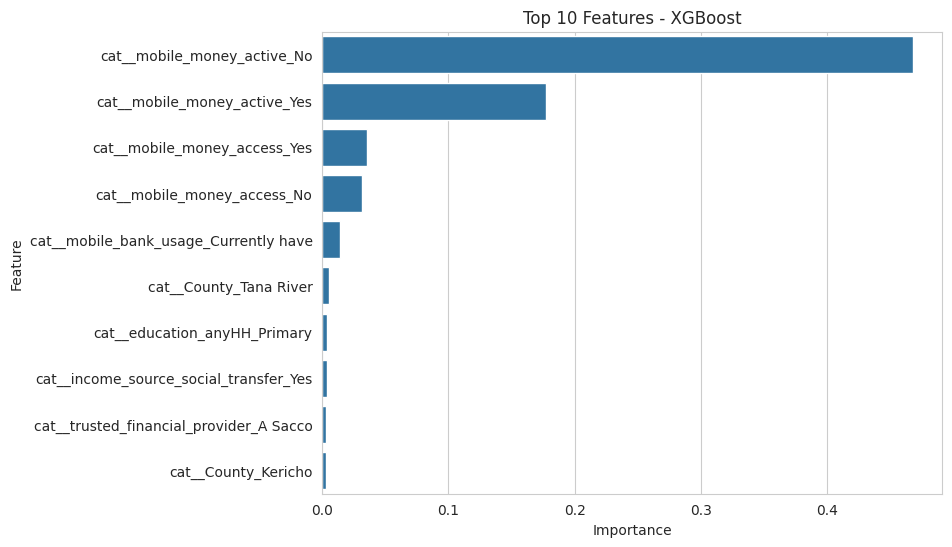

In [69]:
#Plot feature importance


top_features = xgb_importance.head(10)

plt.figure(figsize=(8,6))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 10 Features - XGBoost")
plt.show()

## Catboost

In [70]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.8 MB/s eta 0:00:00:00:0100:01


In [71]:
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import classification_report, roc_auc_score

In [72]:
#Build pipeline for CatBoost with similar structure to previous models, but with specific hyperparameters to handle class imbalance and optimize performance
cat_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", VarianceThreshold(0.01)),
    ("model", CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',
        verbose=0,
        random_state=42,
        auto_class_weights='Balanced'
    ))
])

In [73]:
#Train the model
cat_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['cluster_number',
                                                   'respondent_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['County', 'cluster_type',
                                                   'respondent_sex',
                                                   'education_completed_raw',
                                                   'education_completed_other',
                                                   'female_hh_highest_education',
                                                   'emergency_access_area_type',
                                                   'in...
                                                   'mobile_money_barrier_untrustworthy_agents',
                                                   'formal_account_barrier_distrust',
                                                   'cost_to_nearest_bank',
                                                   'walk_time_to_nearest_bank',
                                                   'cost_to_nearest_mobile_money_agent', ...])])),
                ('feature_selection', VarianceThreshold(threshold=0.01)),
                ('model',
                 CatBoostClassifier(auto_class_weights='Balanced', depth=6, iterations=200, learning_rate=0.1, loss_function='Logloss', random_state=42, verbose=0))])

In [74]:
#Predictions
y_pred_cat = cat_pipeline.predict(X_test)
y_prob_cat = cat_pipeline.predict_proba(X_test)[:, 1]

In [75]:
#Evaluate
print(classification_report(y_test, y_pred_cat))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_cat))


              precision    recall  f1-score   support

           0       0.76      0.97      0.85       925
           1       0.99      0.92      0.95      3480

    accuracy                           0.93      4405
   macro avg       0.88      0.94      0.90      4405
weighted avg       0.94      0.93      0.93      4405

ROC-AUC: 0.9829934762348554


In [76]:
#Feature importance
preprocessor_fitted = cat_pipeline.named_steps["preprocessing"]
selector = cat_pipeline.named_steps["feature_selection"]
model = cat_pipeline.named_steps["model"]

all_features = preprocessor_fitted.get_feature_names_out()
selected_features = all_features[selector.get_support()]

importances = model.get_feature_importance()

import pandas as pd
cat_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(cat_importance.head(15))

                                               Feature  Importance
166                        cat__mobile_money_active_No   29.477405
167                       cat__mobile_money_active_Yes   12.111385
154              cat__mobile_bank_usage_Currently have    9.156777
1                                  num__respondent_age    6.679614
165                       cat__mobile_money_access_Yes    5.295671
164                        cat__mobile_money_access_No    4.935013
0                                  num__cluster_number    2.917352
137  cat__cost_to_nearest_bank_agent_More than KSh 500    0.823860
55   cat__education_completed_raw_"Secondary comple...    0.822610
109  cat__trusted_financial_provider_Mobile money p...    0.785062
106             cat__trusted_financial_provider_A bank    0.752450
179                   cat__incomegp_new_KSh 7501-15000    0.665151
156                cat__mobile_bank_usage_Used to have    0.644101
144                             cat__education_Primary    0.60

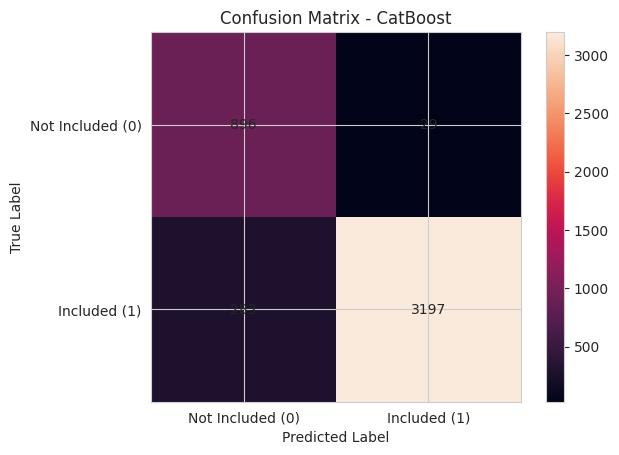

In [77]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_cat = cat_pipeline.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_cat)

# Plot manually (cleaner for reports)
plt.figure()

plt.imshow(cm)
plt.title("Confusion Matrix - CatBoost")

plt.colorbar()

labels = ["Not Included (0)", "Included (1)"]
plt.xticks(np.arange(2), labels)
plt.yticks(np.arange(2), labels)

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

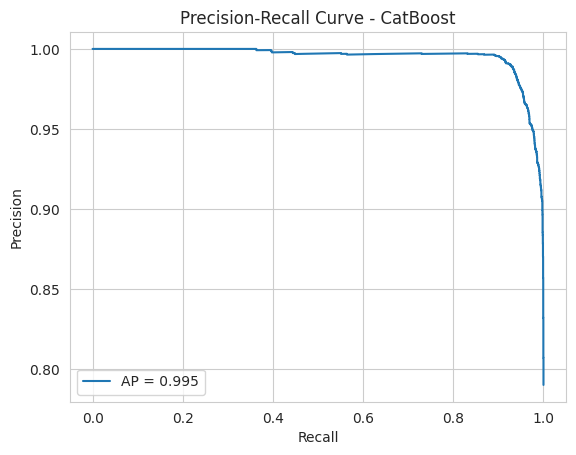

In [78]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute values
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_cat)
pr_auc = average_precision_score(y_test, y_prob_cat)

# Plot
plt.figure()
plt.plot(recall, precision, label=f"AP = {pr_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - CatBoost")
plt.legend(loc="lower left")

plt.show()

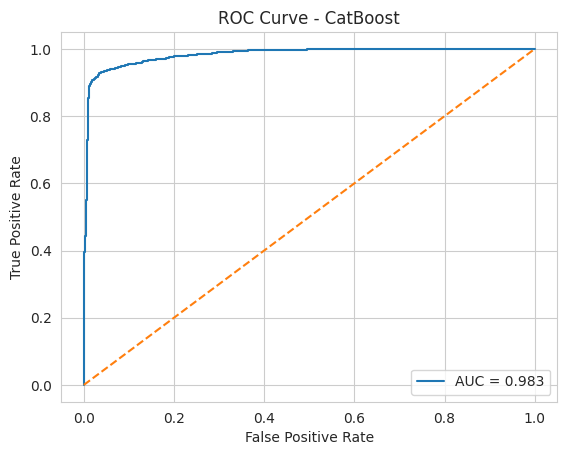

In [79]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities
y_prob_cat = cat_pipeline.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_cat)
roc_auc = roc_auc_score(y_test, y_prob_cat)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # diagonal

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CatBoost")
plt.legend(loc="lower right")

plt.show()

## Neural Network Models
TabM (Deep Learning Benchmark)

In [80]:
# Prepare data
X_tabm = X_processed_df.drop(columns=["financially_included"])
y_tabm = X_processed_df["financially_included"]

In [81]:
#Train-test split
from sklearn.model_selection import train_test_split

X_train_tabm, X_test_tabm, y_train_tabm, y_test_tabm = train_test_split(
    X_tabm, y_tabm,
    test_size=0.2,
    random_state=42,
    stratify=y_tabm
)

In [82]:
#Convert to tensors
import torch

X_train_tensor = torch.tensor(X_train_tabm.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_tabm.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_tabm.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_tabm.values, dtype=torch.float32)


In [83]:
#Define TabM model (improved version of TabNet with better handling of tabular data and interpretability)
import torch.nn as nn

class TabM(nn.Module):
    def __init__(self, input_dim):
        super(TabM, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.network(x)

In [84]:
#Initialize model
input_dim = X_train_tensor.shape[1]

model = TabM(input_dim)

criterion = nn.BCEWithLogitsLoss()  # better than Sigmoid + BCELoss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [85]:


# Compute class weight
pos_weight = torch.tensor(
    [(y_train_tabm == 0).sum() / (y_train_tabm == 1).sum()],
    dtype=torch.float32
)

# Define loss function
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [86]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [87]:
#Train model
epochs = 40  # slightly increase training

for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()
    
    outputs = model(X_train_tensor).squeeze()
    loss = criterion(outputs, y_train_tensor)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.2959
Epoch 5, Loss: 0.2081
Epoch 10, Loss: 0.1433
Epoch 15, Loss: 0.1038
Epoch 20, Loss: 0.0824
Epoch 25, Loss: 0.0696
Epoch 30, Loss: 0.0620
Epoch 35, Loss: 0.0571


In [88]:
#Evaluate
import numpy as np
from scipy.special import expit  # sigmoid

model.eval()

with torch.no_grad():
    logits = model(X_test_tensor).squeeze().numpy()
    y_prob_tabm = expit(logits)  # convert to probability
    y_pred_tabm = (y_prob_tabm > 0.5).astype(int)

In [90]:
#Metrics
from sklearn.metrics import classification_report, roc_auc_score, f1_score

print(classification_report(y_test_tabm, y_pred_tabm))
print("ROC-AUC:", roc_auc_score(y_test_tabm, y_prob_tabm))
print("F1 Score:", f1_score(y_test_tabm, y_pred_tabm))


              precision    recall  f1-score   support

           0       0.78      0.95      0.86       925
           1       0.99      0.93      0.96      3480

    accuracy                           0.93      4405
   macro avg       0.88      0.94      0.91      4405
weighted avg       0.94      0.93      0.94      4405

ROC-AUC: 0.9810071450761105
F1 Score: 0.956534594914252


In [110]:
import os
import shutil
from datetime import datetime

# 1. Define paths
# This is where your cloud work lives
source_folder = '/content/project' 
# This is the permanent home on your Drive
backup_drive_path = '/content/drive/MyDrive/New project/backups' 

# 2. Create the backup folder on Drive if it doesn't exist
if not os.path.exists(backup_drive_path):
    os.makedirs(backup_drive_path)
    print(f"Created backup directory: {backup_drive_path}")

# 3. Create a timestamped filename (e.g., project_backup_2024-05-20_14-30)
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
zip_filename = f"project_backup_{timestamp}"
full_zip_path = os.path.join(backup_drive_path, zip_filename)

print(f"📦 Starting backup of {source_folder}...")

# 4. Zip and Save directly to Drive
# shutil.make_archive automatically adds '.zip' to the end
try:
    shutil.make_archive(full_zip_path, 'zip', source_folder)
    print(f"✅ Success! Backup saved to: {full_zip_path}.zip")
except Exception as e:
    print(f"❌ Backup failed: {e}")


📦 Starting backup of /content/project...
✅ Success! Backup saved to: /content/drive/MyDrive/New project/backups/project_backup_2026-04-22_04-43.zip
